# EEG Alpha Functions Step-by-Step Test

This notebook tests functions from `ppg_eeg.eeg` on one existing EEG file in this repo.

Functions tested:
- `compute_mean_psd_linear`
- `alpha_peak_from_spectrum`
- `alpha_peak`
- `alpha_peak_frequency`
- `plot_alpha_peak`


In [1]:
%matplotlib inline

from pathlib import Path
import numpy as np
import mne
import matplotlib.pyplot as plt

from ppg_eeg.eeg import (
    POSTERIOR_ELECTRODES,
    compute_mean_psd_linear,
    alpha_peak_from_spectrum,
    alpha_peak,
    alpha_peak_frequency,
    plot_alpha_peak,
)


In [2]:
# Choose one existing EEG file from your repo
candidate_files = sorted(Path("data/raw").rglob("*.vhdr"))
if not candidate_files:
    raise FileNotFoundError("No BrainVision .vhdr file found under data/raw")

# Use the first available file so the notebook is reproducible
eeg_vhdr_path = candidate_files[0]
print("Selected EEG file:", eeg_vhdr_path)


Selected EEG file: data/raw/HIIT/HIIT_01_PH/HIIT_01_PH_POST.vhdr


In [3]:
# Load EEG and keep EEG channels only
raw = mne.io.read_raw_brainvision(eeg_vhdr_path, preload=True, verbose="ERROR")
raw.pick_types(eeg=True)

print(raw)
print("Sampling frequency:", raw.info["sfreq"])
print("Number of EEG channels:", len(raw.ch_names))


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
<RawBrainVision | HIIT_01_PH_POST.eeg, 63 x 152340 (304.7 s), ~73.3 MiB, data loaded>
Sampling frequency: 500.0
Number of EEG channels: 63


In [4]:
# Select channels for posterior alpha analysis
channels = [ch for ch in POSTERIOR_ELECTRODES if ch in raw.ch_names]
print("Using posterior channels:", channels)
print("Count:", len(channels))

if not channels:
    raise ValueError("None of POSTERIOR_ELECTRODES exist in this file.")


Using posterior channels: ['CP1', 'CP2', 'CP3', 'CP4', 'CP5', 'CP6', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'POz', 'PO3', 'PO4', 'O1', 'O2', 'Oz']
Count: 18


In [5]:
# Step 1: compute_mean_psd_linear
freqs, mean_power = compute_mean_psd_linear(
    raw,
    channels,
    fmin=1.0,
    fmax=30.0,
    n_fft=2048,
)

print("freqs shape:", freqs.shape)
print("mean_power shape:", mean_power.shape)
print("First 10 freqs:", freqs[:10])
print("First 10 power values:", mean_power[:10])


freqs shape: (118,)
mean_power shape: (118,)
First 10 freqs: [1.22070312 1.46484375 1.70898438 1.953125   2.19726562 2.44140625
 2.68554688 2.9296875  3.17382812 3.41796875]
First 10 power values: [5.0021952  3.78075115 3.03748591 2.688014   2.36485159 1.63764154
 1.2554025  1.5673833  1.39777399 1.14211029]


In [6]:
# Step 2: alpha_peak_from_spectrum
peak_freq_from_spec, peak_power_from_spec = alpha_peak_from_spectrum(
    freqs,
    mean_power,
    alpha_range=(5.0, 16.0),
    smooth_sigma=1.0,
    min_height_ratio=0.5,
)

print("alpha_peak_from_spectrum -> peak frequency (Hz):", peak_freq_from_spec)
print("alpha_peak_from_spectrum -> peak power (uV^2/Hz):", peak_power_from_spec)


alpha_peak_from_spectrum -> peak frequency (Hz): 11.23046875
alpha_peak_from_spectrum -> peak power (uV^2/Hz): 11.633881018937105


In [7]:
# Step 3: alpha_peak
peak_result = alpha_peak(
    raw,
    channels=channels,
    alpha_range=(5.0, 16.0),
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
    smooth_sigma=1.0,
    min_height_ratio=0.5,
)

print("alpha_peak result:", peak_result)
print("alpha_peak -> frequency_hz:", peak_result.frequency_hz)
print("alpha_peak -> power_uv2_hz:", peak_result.power_uv2_hz)


alpha_peak result: AlphaPeakResult(frequency_hz=11.23046875, power_uv2_hz=11.633881018937105)
alpha_peak -> frequency_hz: 11.23046875
alpha_peak -> power_uv2_hz: 11.633881018937105


In [8]:
# Step 4: alpha_peak_frequency
peak_frequency_only = alpha_peak_frequency(
    raw,
    channels=channels,
    alpha_range=(5.0, 16.0),
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
    smooth_sigma=1.0,
    min_height_ratio=0.5,
)

print("alpha_peak_frequency ->", peak_frequency_only)


alpha_peak_frequency -> 11.23046875


plot_alpha_peak -> peak_frequency_hz: 11.23046875
plot_alpha_peak -> peak_power_uv2_hz: 11.633881018937105


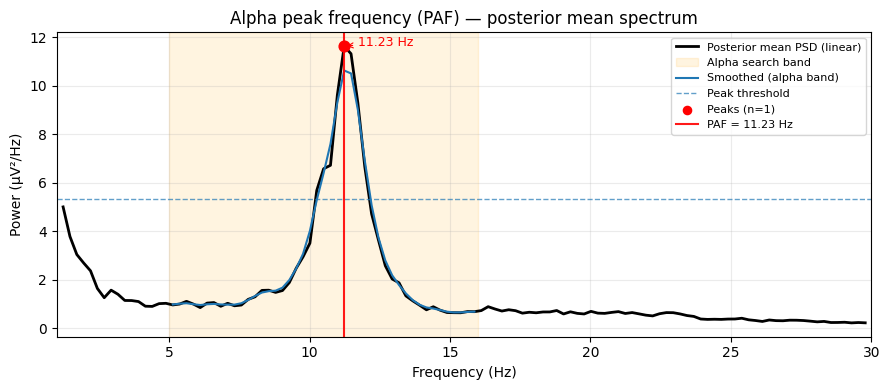

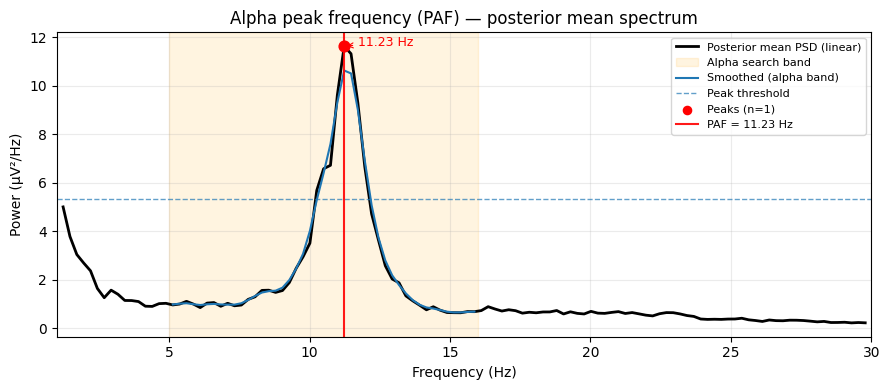

In [9]:
# Step 5: plot_alpha_peak
plot_result = plot_alpha_peak(
    raw,
    channels=channels,
    alpha_range=(5.0, 16.0),
    psd_fmin=1.0,
    psd_fmax=30.0,
    n_fft=2048,
    smooth_sigma=1.0,
    min_height_ratio=0.5,
    annotate_peaks=True,
)

print("plot_alpha_peak -> peak_frequency_hz:", plot_result.peak_frequency_hz)
print("plot_alpha_peak -> peak_power_uv2_hz:", plot_result.peak_power_uv2_hz)
display(plot_result.fig)
